## 파이썬을 활용한 데이터 시각화

- 데이터셋 :  자연재난상황통계_시도_태풍_2012_2021
- 10년간 태풍과 관련된 피해금액
- 재난 피해금액 데이터 : 자연재난상황통계

In [16]:
!pip3 install pandas
!pip3 install koreanize_matplotlib
!pip3 install seaborn
!pip3 install pandas matplotlib seaborn openpyxl # openpyxl은 엑셀 파일을 읽기 위한 라이브러리

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.9 MB 6.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
## 데이터셋 확인하기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Practice Data/자연재난상황통계_시도_태풍_2012_2021.xlsx")
df.head() #데이터셋의 상위 5행을 확인

print(df.info()) #데이터셋의 기본적인 정보 모두 확인 가능

df = df.fillna(0) # 결측값을 0으로 채우기 
print(df)


# 필요한 칼럼만 추출하기
df = df[['합계(천원) ']]
df


,합계(천원)
0,886635
1,859252
2,63950344
3,58369685
4,96630
5,91755
6,15981904
7,15219751
8,18858385
9,18293095


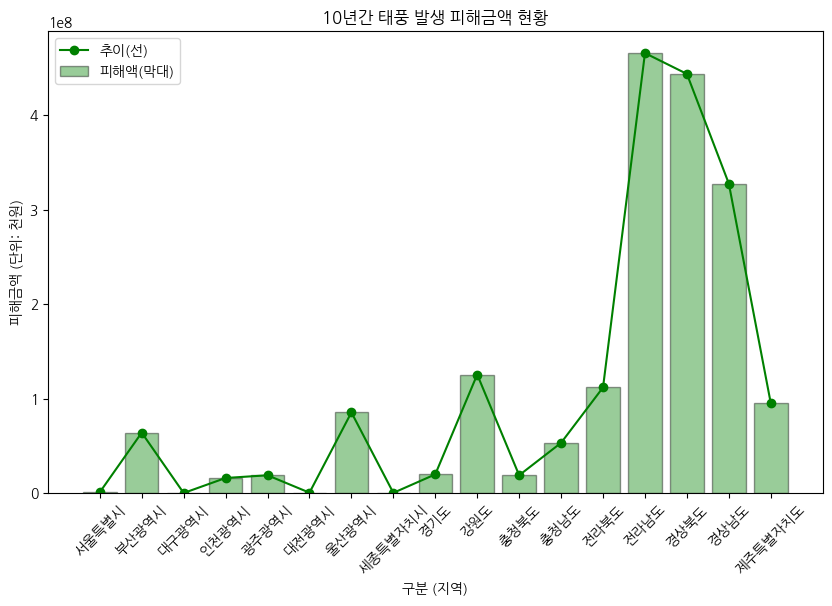

In [47]:
## matplotlib로 bar + plot 그래프 그리기

import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 데이터 불러오기
df = pd.read_excel("Practice Data/자연재난상황통계_시도_태풍_2012_2021.xlsx")

# [에러 해결 핵심 코드]
df = df.dropna(subset=['구분']) # 빈 행 제거
df['구분'] = df['구분'].astype(str) # 모두 문자로 변환

# '구분'이 '합계'인 행 제외하기
# 만약 '전국합계' 등 다른 글자가 포함되어 있다면 df['구분'].str.contains('합계') == False 를 쓸 수도 있습니다.
df = df[df['구분'] != '합계']

plt.figure(figsize=(10, 6))

# 막대 그래프와 선 그래프 그리기
plt.bar(df['구분'], df['합계(천원)'], color='green', edgecolor='black', alpha=0.4, label='피해액(막대)')
plt.plot(df['구분'], df['합계(천원)'], color='green', marker='o', label='추이(선)')

plt.title('10년간 태풍 발생 피해금액 현황')
plt.xlabel('구분 (지역)')
plt.ylabel('피해금액 (단위: 천원)')
plt.xticks(rotation=45)
plt.legend()

plt.show()

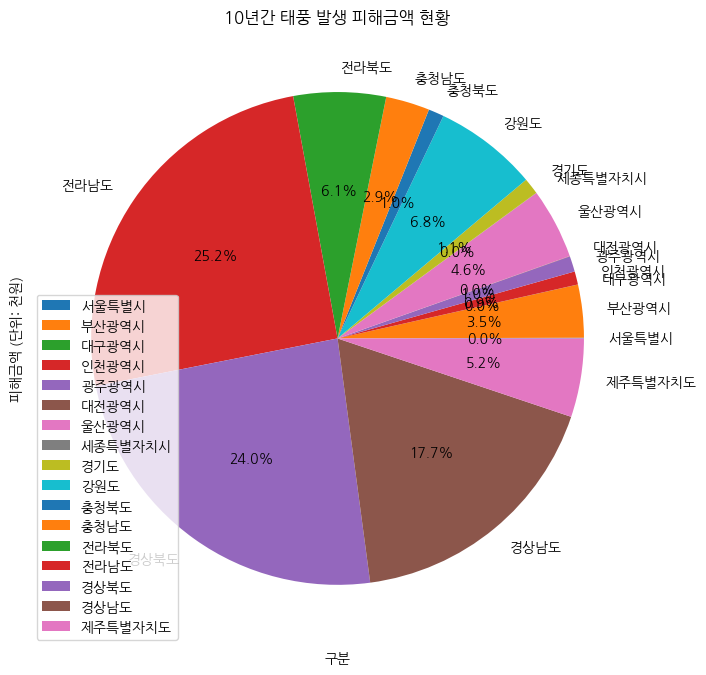

In [ ]:
## matplotlib로 pie 차트 그래프 그리기

import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 데이터 불러오기
df = pd.read_excel("Practice Data/자연재난상황통계_시도_태풍_2012_2021.xlsx")

# [에러 해결 핵심 코드]
df = df.dropna(subset=['구분']) # 빈 행 제거
df['구분'] = df['구분'].astype(str) # 모두 문자로 변환

# '구분'이 '합계'인 행 제외하기
# 만약 '전국합계' 등 다른 글자가 포함되어 있다면 df['구분'].str.contains('합계') == False 를 쓸 수도 있습니다.
df = df[df['구분'] != '합계']

plt.figure(figsize=(8,8))

plt.pie(x=df['합계(천원)'], labels=df['구분'], autopct='%.1f%%') #소수 첫째자리까지
plt.title('10년간 태풍 발생 피해금액 현황')
plt.xlabel('구분')
plt.ylabel('피해금액 (단위: 천원)')

plt.legend()
plt.show()

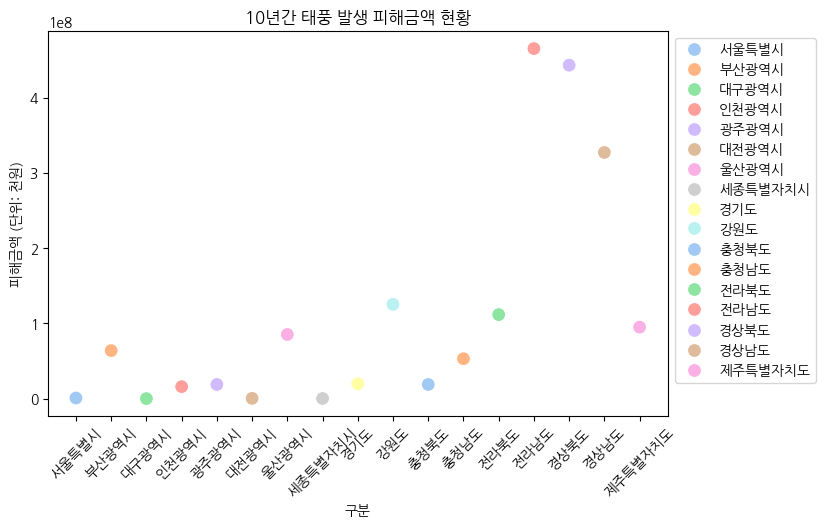

In [45]:
## seaborn으로 scatterplot 그래프 그리기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_excel("Practice Data/자연재난상황통계_시도_태풍_2012_2021.xlsx")

# [에러 해결 핵심 코드]
df = df.dropna(subset=['구분']) # 빈 행 제거
df['구분'] = df['구분'].astype(str) # 모두 문자로 변환

# '구분'이 '합계'인 행 제외하기
# 만약 '전국합계' 등 다른 글자가 포함되어 있다면 df['구분'].str.contains('합계') == False 를 쓸 수도 있습니다.
df = df[df['구분'] != '합계']

plt.figure(figsize=(8,5))

sns.scatterplot(x=df['구분'], y=df['합계(천원)'], palette='pastel', hue=df['구분'],s=100)

plt.title('10년간 태풍 발생 피해금액 현황')
plt.xlabel('구분')
plt.ylabel('피해금액 (단위: 천원)')
plt.xticks(rotation=45)

plt.legend(loc="upper left", bbox_to_anchor=[1,1]) #범례의 위치를 설정
plt.show()

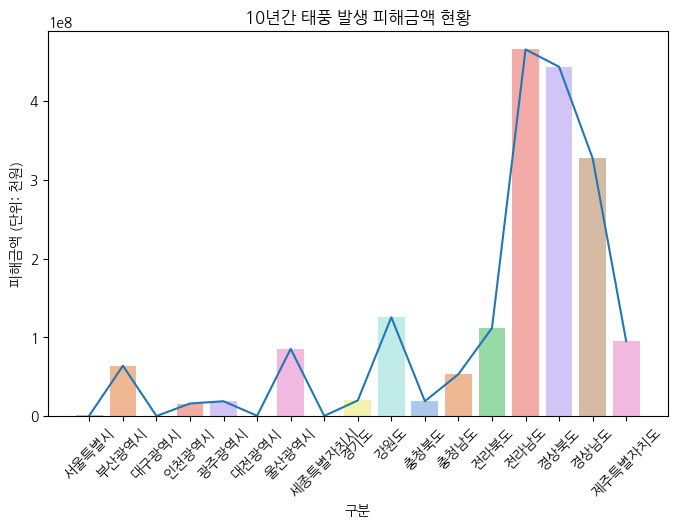

In [46]:
## seaborn으로 barplot + lineplot 그래프 그리기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_excel("Practice Data/자연재난상황통계_시도_태풍_2012_2021.xlsx")

# [에러 해결 핵심 코드]
df = df.dropna(subset=['구분']) # 빈 행 제거
df['구분'] = df['구분'].astype(str) # 모두 문자로 변환

# '구분'이 '합계'인 행 제외하기
# 만약 '전국합계' 등 다른 글자가 포함되어 있다면 df['구분'].str.contains('합계') == False 를 쓸 수도 있습니다.
df = df[df['구분'] != '합계']

plt.figure(figsize=(8,5))

sns.barplot(x=df['구분'],y=df['합계(천원)'], palette='pastel', hue=df['구분'])
sns.lineplot(x=df['구분'],y=df['합계(천원)'])

plt.title('10년간 태풍 발생 피해금액 현황')
plt.xlabel('구분')
plt.ylabel('피해금액 (단위: 천원)')
plt.xticks(rotation=45)

plt.show()
